# LV 几何 AHA 分区 5 组染色可视化（v6：5组着色 + 17区/5组双层边界 + 论文终稿风格）

本版本将 AHA 17 个分区按以下 5 组重新染色：
- anterior: (1, 7)
- lateral: (5, 6, 11, 12)
- inferior: (4, 10)
- septal: (2, 3, 8, 9)
- apical: (13–17)

同时保留两层边界信息：
- **细线**：AHA 17 区内部边界；
- **粗线**：5 组之间的边界。

静态图适合论文最终出图，配色采用色盲友好方案；另外保留 notebook 内可交互旋转查看。


## 运行前准备

```bash
pip install pyvista vtk scipy matplotlib h5py
```

Linux 服务器 / 容器若无显示服务器：

```bash
sudo apt-get install -y xvfb libgl1-mesa-glx
```

In [1]:
import os
from pathlib import Path
import tempfile

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.io import loadmat

try:
    import h5py   # 仅用于 MATLAB v7.3 文件回退读取
except Exception:
    h5py = None

import pyvista as pv

# headless 环境尝试启动 xvfb（macOS/Windows 会静默失败）
try:
    pv.start_xvfb()
except Exception:
    pass

# 统一 PyVista 背景
pv.global_theme.background = "white"

print("PyVista version :", pv.__version__)
print("VTK version     :", pv.vtk_version_info)


PyVista version : 0.47.3
VTK version     : (9, 6, 1)


C:\Users\r4718\AppData\Local\Temp\ipykernel_29468\2741029951.py:21: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


In [3]:
# =========================
# 1) 用户配置：只需修改这里
# =========================
inp_path = "hexheartLVmeshF60S45.inp"
mat_path = "AHALVMeshDivisionPCAReconstructed.mat"

# 输出路径
output_dir = "output_dir"
figure_name = "lv_aha5_grouped_surface_cutaway.png"
vtu_name = "lv_aha17_mesh.vtu"
save_vtu = True

# 背景模式："white" 或 "transparent"
bg_mode = "white"

# 图像参数
window_size = (2400, 1100)
parallel_projection = True
mpl_dpi = 240
zoom_factor = 1.10

# 透明度：主彩色表面的统一透明度参数
mesh_opacity = 0.86

# AHA 17 区边界（细线）
show_aha17_boundaries = True
aha17_boundary_color = "#F7F7F7"
aha17_boundary_line_width = 0.65
aha17_boundary_opacity = 0.95

# 5 组边界（粗线）
show_aha5_boundaries = True
aha5_boundary_color = "#222222"
aha5_boundary_line_width = 1.50
aha5_boundary_opacity = 0.98

# 是否保留整体网格叠加（浅灰色线框）
show_mesh_overlay = True
mesh_overlay_color = "#7A7A7A"
mesh_overlay_line_width = 0.32
mesh_overlay_opacity = 0.16

# 是否显式显示原始冲突位置（默认关闭，因为现在冲突都归为 apicalRegion）
show_conflict_overlay = False

# 单独查看的组：这里按要求固定为 lateral
single_group_name = "Lateral"
single_group_id = 2
single_group_figure_name = "lv_lateral_group_only.png"

# 交互旋转（建议在 JupyterLab / Notebook 中使用）
interactive_backend = "trame"   # 也可改为 "static" / "html"
interactive_window_size = (1600, 800)


In [4]:
# =========================
# 2) AHA 17 标签、5 组定义与色盲友好配色
# =========================
REGION_NAMES = {
    1: "Segment 1",
    2: "Segment 2",
    3: "Segment 3",
    4: "Segment 4",
    5: "Segment 5",
    6: "Segment 6",
    7: "Segment 7",
    8: "Segment 8",
    9: "Segment 9",
    10: "Segment 10",
    11: "Segment 11",
    12: "Segment 12",
    13: "Segment 13",
    14: "Segment 14",
    15: "Segment 15",
    16: "Segment 16",
    17: "Segment 17",
}

# AHA 17 -> 5 组映射（严格按照用户给出的编号规则）
AHA17_TO_AHA5 = {
    1: 1, 7: 1,                              # anterior
    5: 2, 6: 2, 11: 2, 12: 2,               # lateral
    4: 3, 10: 3,                            # inferior
    2: 4, 3: 4, 8: 4, 9: 4,                 # septal
    13: 5, 14: 5, 15: 5, 16: 5, 17: 5,      # apical
}

AHA5_GROUP_NAMES = {
    1: "Anterior",
    2: "Lateral",
    3: "Inferior",
    4: "Septal",
    5: "Apical",
}

# 色盲友好的 5 色方案（基于论文常用、印刷友好的高区分度配色）
AHA5_COLORS = [
    "#332288",  # Anterior - deep blue
    "#44AA99",  # Lateral  - teal
    "#DDCC77",  # Inferior - sand
    "#AA4499",  # Septal   - purple
    "#CC6677",  # Apical   - rose
]

AHA5_CMAP = ListedColormap(AHA5_COLORS, name="aha5_grouped")
AHA5_ANNOTATIONS = {float(i): AHA5_GROUP_NAMES[i] for i in range(1, 6)}


In [5]:
# =========================
# 3) 读取 .mat 和 .inp
# =========================
AHA17_ELEM_FIELD_MAP = [
    ("elem_basa_InfSept", 1),
    ("elem_basa_AntSept", 2),
    ("elem_basa_Ant", 3),
    ("elem_base_AntLat", 4),
    ("elem_base_InfLat", 5),
    ("elem_base_Inf", 6),
    ("elem_midd_InfSept", 7),
    ("elem_midd_AntSept", 8),
    ("elem_midd_Ant", 9),
    ("elem_midd_AntLat", 10),
    ("elem_midd_InfLat", 11),
    ("elem_midd_Inf", 12),
    ("elem_apex_Sept", 13),
    ("elem_apex_Ant", 14),
    ("elem_apex_Lat", 15),
    ("elem_apex_Inf", 16),
    ("elem_apicalRegion", 17),
]


def _load_mat_fallback_v73(mat_file):
    raise RuntimeError(
        "当前 notebook 的分区重建依赖 scipy.io.loadmat 读取 MATLAB 结构体；"
        "检测到可能是 v7.3/HDF5 格式，请先将 .mat 另存为非 v7.3 格式后再运行。"
    )


def _as_1d_int_array(x):
    arr = np.asarray(x).reshape(-1)
    if arr.size == 0:
        return arr.astype(np.int64)
    if np.issubdtype(arr.dtype, np.number):
        arr = arr[np.isfinite(arr)]
    return arr.astype(np.int64)


def load_regions_from_mat(mat_file, n_cells_expected):
    """
    从 AHALVMeshDivision 中：
    1) 读取 nodeRegions
    2) 用 17 个 elem_* 字段重建 el_regions
    3) 若存在冲突，则冲突单元统一归入 elem_apicalRegion (AHA17 = 17)

    返回
    ----
    node_regions : (n_points,) int32
    el_regions   : (n_cells,) int32
    conflict_mask: (n_cells,) bool
    """
    try:
        mat = loadmat(mat_file, squeeze_me=True, struct_as_record=False)
    except NotImplementedError:
        return _load_mat_fallback_v73(mat_file)

    if "AHALVMeshDivision" not in mat:
        raise KeyError("MAT 文件中没有找到 'AHALVMeshDivision'。")

    s = mat["AHALVMeshDivision"]

    if hasattr(s, "nodeRegions"):
        node_regions = _as_1d_int_array(s.nodeRegions).astype(np.int32)
    else:
        node_regions = _as_1d_int_array(s["nodeRegions"]).astype(np.int32)

    el_regions = np.zeros(n_cells_expected, dtype=np.int32)
    hit_count = np.zeros(n_cells_expected, dtype=np.int32)
    conflict_mask = np.zeros(n_cells_expected, dtype=bool)

    missing_fields = []

    for field_name, region_id in AHA17_ELEM_FIELD_MAP:
        if hasattr(s, field_name):
            elem_ids = _as_1d_int_array(getattr(s, field_name))
        elif isinstance(s, dict) and field_name in s:
            elem_ids = _as_1d_int_array(s[field_name])
        else:
            missing_fields.append(field_name)
            continue

        if elem_ids.size == 0:
            continue

        elem_idx = np.unique(elem_ids - 1)  # Abaqus / MATLAB IDs are 1-based

        bad = (elem_idx < 0) | (elem_idx >= n_cells_expected)
        if np.any(bad):
            raise ValueError(
                f"{field_name} contains out-of-range element ids: "
                f"{(elem_idx[bad][:10] + 1).tolist()}"
            )

        first_hit = (hit_count[elem_idx] == 0)
        el_regions[elem_idx[first_hit]] = region_id

        hit_count[elem_idx] += 1
        conflict_mask[elem_idx[hit_count[elem_idx] > 1]] = True

    if missing_fields:
        raise ValueError(f"Missing elem_* fields in MAT file: {missing_fields}")

    unassigned = np.where(hit_count == 0)[0]
    if unassigned.size > 0:
        raise ValueError(
            f"{unassigned.size} elements are not covered by the 17 elem_* fields. "
            f"Sample 1-based ids: {(unassigned[:10] + 1).tolist()}"
        )

    # 关键修改：所有冲突单元统一归入 elem_apicalRegion
    n_conflict = int(conflict_mask.sum())
    if n_conflict > 0:
        el_regions[conflict_mask] = 17

    print(f"[AHA rebuild] total cells            : {n_cells_expected}")
    print(f"[AHA rebuild] conflict cells         : {n_conflict}")
    print(f"[AHA rebuild] conflicts -> region 17 : {n_conflict}")
    if n_conflict > 0:
        sample_ids = (np.where(conflict_mask)[0][:10] + 1).tolist()
        print(f"[AHA rebuild] sample conflict element ids: {sample_ids}")

    return node_regions, el_regions, conflict_mask


def parse_abaqus_inp(inp_file):
    """
    解析 Abaqus .inp 中的：
    - *Node
    - *Element, type=C3D8 / C3D8H
    """
    node_ids = []
    points = []
    elem_ids = []
    elem_conn_node_ids = []

    in_nodes = False
    in_elements = False
    element_is_hex8 = False

    with open(inp_file, "r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            line = raw.strip()

            if not line or line.startswith("**"):
                continue

            if line.startswith("*"):
                upper = line.upper()
                in_nodes = upper.startswith("*NODE")
                in_elements = upper.startswith("*ELEMENT")
                element_is_hex8 = False
                if in_elements and ("TYPE=C3D8" in upper or "TYPE=C3D8H" in upper):
                    element_is_hex8 = True
                continue

            if in_nodes:
                parts = [p.strip() for p in line.split(",") if p.strip()]
                if len(parts) >= 4:
                    node_ids.append(int(parts[0]))
                    points.append([float(parts[1]), float(parts[2]), float(parts[3])])
            elif in_elements and element_is_hex8:
                parts = [p.strip() for p in line.split(",") if p.strip()]
                if len(parts) < 9:
                    raise ValueError(f"六面体单元连通性读取失败，当前行：{line}")
                elem_ids.append(int(parts[0]))
                elem_conn_node_ids.append([int(x) for x in parts[1:9]])

    node_ids = np.asarray(node_ids, dtype=np.int64)
    points = np.asarray(points, dtype=np.float64)
    elem_ids = np.asarray(elem_ids, dtype=np.int64)
    elem_conn_node_ids = np.asarray(elem_conn_node_ids, dtype=np.int64)

    if node_ids.size == 0:
        raise RuntimeError("没有从 .inp 中解析到节点。")
    if elem_ids.size == 0:
        raise RuntimeError("没有从 .inp 中解析到 C3D8/C3D8H 单元。")

    max_id = int(node_ids.max())
    lookup = np.full(max_id + 2, -1, dtype=np.int64)
    lookup[node_ids] = np.arange(node_ids.size, dtype=np.int64)

    conn = lookup[elem_conn_node_ids]
    if (conn < 0).any():
        missing = elem_conn_node_ids[conn < 0][:5]
        raise RuntimeError(f"单元引用了未定义的节点 ID，例如：{missing.tolist()}")

    return node_ids, points, elem_ids, conn


In [6]:
# =========================
# 4) 构造 PyVista 网格
# =========================
def build_unstructured_grid(points, conn, node_regions, el_regions, conflict_mask):
    if len(points) != len(node_regions):
        raise ValueError(
            f"节点数不一致：mesh 有 {len(points)} 个节点，但 nodeRegions 长度为 {len(node_regions)}。"
        )
    if len(conn) != len(el_regions):
        raise ValueError(
            f"单元数不一致：mesh 有 {len(conn)} 个单元，但 elRegions 长度为 {len(el_regions)}。"
        )
    if len(conn) != len(conflict_mask):
        raise ValueError(
            f"单元数不一致：mesh 有 {len(conn)} 个单元，但 conflict_mask 长度为 {len(conflict_mask)}。"
        )

    # 构造 5 组标签
    aha5 = np.array([AHA17_TO_AHA5[int(x)] for x in el_regions], dtype=np.int32)

    n_cells = conn.shape[0]
    cells = np.hstack(
        [np.full((n_cells, 1), 8, dtype=np.int64), conn.astype(np.int64)]
    ).ravel()
    celltypes = np.full(n_cells, pv.CellType.HEXAHEDRON, dtype=np.uint8)

    grid = pv.UnstructuredGrid(cells, celltypes, points)
    grid.cell_data["AHA17"] = el_regions.astype(np.int32)
    grid.cell_data["AHA5"] = aha5.astype(np.int32)
    grid.cell_data["AHA17_conflict"] = conflict_mask.astype(np.uint8)
    grid.point_data["AHA17_nodes"] = node_regions.astype(np.int32)
    return grid


def maybe_save_vtu(grid, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    grid.save(out_path)
    return out_path


In [7]:
# =========================
# 5) 渲染：5 组染色 + 17 区/5 组双层边界
# =========================
from matplotlib.lines import Line2D


def compute_camera(bounds):
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    center = np.array(
        [(xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2], dtype=float
    )
    extents = np.array([xmax - xmin, ymax - ymin, zmax - zmin], dtype=float)
    diag = np.linalg.norm(extents)
    position = center + np.array([1.35, -1.85, 1.05]) * diag
    viewup = (0.0, 0.0, 1.0)
    return [tuple(position), tuple(center), viewup]


def _draw_group_legend(ax, ncol=5, fontsize=10):
    patch_handles = [
        mpatches.Patch(
            facecolor=AHA5_COLORS[i - 1],
            edgecolor="#444444",
            linewidth=0.7,
            label=AHA5_GROUP_NAMES[i],
        )
        for i in range(1, 6)
    ]
    line_handles = [
        Line2D([0], [0], color=aha17_boundary_color, lw=aha17_boundary_line_width + 0.6,
               label="AHA 17 boundaries"),
        Line2D([0], [0], color=aha5_boundary_color, lw=aha5_boundary_line_width,
               label="5-group boundaries"),
    ]
    handles = patch_handles + line_handles
    ax.axis("off")
    ax.legend(
        handles=handles,
        loc="center",
        ncol=ncol,
        fontsize=fontsize,
        frameon=False,
        handlelength=1.8,
        handleheight=1.0,
        columnspacing=1.5,
        borderaxespad=0,
    )


def _extract_conflict_grid(grid):
    if "AHA17_conflict" not in grid.cell_data:
        return None
    conflict_idx = np.flatnonzero(grid.cell_data["AHA17_conflict"] > 0)
    if conflict_idx.size == 0:
        return None
    return grid.extract_cells(conflict_idx)


def _prepare_display_surface(dataset, triangulate=True):
    surf = dataset.extract_surface(algorithm=None).clean()
    if triangulate:
        surf = surf.triangulate().clean()
    return surf


def _extract_label_boundaries(surface_mesh, label_name):
    """从着色后的表面提取指定标签体系的边界线。"""
    if label_name not in surface_mesh.cell_data:
        return None
    edge_blocks = []
    labels = np.unique(surface_mesh.cell_data[label_name])
    for rid in labels:
        cell_ids = np.flatnonzero(surface_mesh.cell_data[label_name] == rid)
        if cell_ids.size == 0:
            continue
        sub = surface_mesh.extract_cells(cell_ids)
        edges = sub.extract_feature_edges(
            boundary_edges=True,
            non_manifold_edges=False,
            feature_edges=False,
            manifold_edges=False,
        )
        if edges is not None and edges.n_cells > 0:
            edge_blocks.append(edges)
    if not edge_blocks:
        return None
    merged = edge_blocks[0]
    for e in edge_blocks[1:]:
        merged = merged.merge(e)
    return merged.clean()


def _add_aha5_mesh(plotter, mesh, opacity=0.86):
    plotter.add_mesh(
        mesh,
        scalars="AHA5",
        preference="cell",
        cmap=AHA5_CMAP,
        clim=(0.5, 5.5),
        categories=True,
        annotations=AHA5_ANNOTATIONS,
        show_scalar_bar=False,
        interpolate_before_map=False,
        smooth_shading=True,
        split_sharp_edges=False,
        opacity=opacity,
        ambient=0.30,
        diffuse=0.72,
        specular=0.06,
        lighting=True,
    )


def _add_mesh_overlay(plotter, mesh_wire):
    if (not show_mesh_overlay) or mesh_wire is None or mesh_wire.n_cells == 0:
        return
    plotter.add_mesh(
        mesh_wire,
        style="wireframe",
        color=mesh_overlay_color,
        line_width=mesh_overlay_line_width,
        opacity=mesh_overlay_opacity,
        lighting=False,
    )


def _add_aha17_boundaries(plotter, edge_mesh):
    if (not show_aha17_boundaries) or edge_mesh is None or edge_mesh.n_cells == 0:
        return
    plotter.add_mesh(
        edge_mesh,
        color=aha17_boundary_color,
        line_width=aha17_boundary_line_width,
        opacity=aha17_boundary_opacity,
        lighting=False,
    )


def _add_aha5_boundaries(plotter, edge_mesh):
    if (not show_aha5_boundaries) or edge_mesh is None or edge_mesh.n_cells == 0:
        return
    plotter.add_mesh(
        edge_mesh,
        color=aha5_boundary_color,
        line_width=aha5_boundary_line_width,
        opacity=aha5_boundary_opacity,
        lighting=False,
    )


def _add_conflict_overlay(plotter, dataset, line_width=2.0):
    if (not show_conflict_overlay) or dataset is None or dataset.n_cells == 0:
        return
    surf = _prepare_display_surface(dataset, triangulate=True)
    if surf.n_cells == 0:
        return
    plotter.add_mesh(
        surf,
        color="#111111",
        style="wireframe",
        line_width=line_width,
        opacity=0.95,
        lighting=False,
    )


def _surface_bundle_from_dataset(dataset):
    color_surface = _prepare_display_surface(dataset, triangulate=True)
    wire_surface = _prepare_display_surface(dataset, triangulate=False)
    aha17_edges = _extract_label_boundaries(color_surface, label_name="AHA17")
    aha5_edges = _extract_label_boundaries(color_surface, label_name="AHA5")
    return color_surface, wire_surface, aha17_edges, aha5_edges


def render_pyvista_dual(
    grid,
    window_size=(2400, 1100),
    transparent=False,
    zoom=1.10,
    opacity=0.86,
):
    """
    左：整体表面（5 组染色）
    右：裁切视图（5 组染色）
    细线 = AHA 17 边界，粗线 = 5 组边界。
    """
    center = np.array(grid.center)

    surface_color, surface_wire, surface_aha17_edges, surface_aha5_edges = _surface_bundle_from_dataset(grid)
    clipped = grid.clip(normal=(1.0, 0.0, 0.0), origin=center, invert=False)
    clipped_color, clipped_wire, clipped_aha17_edges, clipped_aha5_edges = _surface_bundle_from_dataset(clipped)

    conflict_grid = _extract_conflict_grid(grid)
    conflict_surface = None
    conflict_clipped = None
    if conflict_grid is not None and conflict_grid.n_cells > 0:
        conflict_surface = conflict_grid
        conflict_clipped = conflict_grid.clip(normal=(1.0, 0.0, 0.0), origin=center, invert=False)

    pl = pv.Plotter(shape=(1, 2), off_screen=True, window_size=window_size, border=False)
    pl.set_background("white")
    camera = compute_camera(grid.bounds)

    panels = [
        (surface_color, surface_wire, surface_aha17_edges, surface_aha5_edges, "Exterior surface", conflict_surface),
        (clipped_color, clipped_wire, clipped_aha17_edges, clipped_aha5_edges, "Cutaway view", conflict_clipped),
    ]

    for col, (mesh_color, mesh_wire, edges17, edges5, title, conflict_mesh) in enumerate(panels):
        pl.subplot(0, col)
        if parallel_projection:
            pl.enable_parallel_projection()
        _add_aha5_mesh(pl, mesh_color, opacity=opacity)
        _add_mesh_overlay(pl, mesh_wire)
        _add_aha17_boundaries(pl, edges17)
        _add_aha5_boundaries(pl, edges5)
        _add_conflict_overlay(pl, conflict_mesh, line_width=2.0)
        pl.add_text(title, position="upper_left", font_size=14, color="black")
        pl.camera_position = camera
        pl.reset_camera()
        pl.camera.zoom(zoom)

    pl.show(auto_close=False)
    img = pl.screenshot(filename=None, transparent_background=transparent, return_img=True)
    pl.close()
    return img


def render_single_group(grid, group_id=2, group_name="Lateral", transparent=False, zoom=1.15, opacity=0.92,
                        window_size=(1500, 1400)):
    """单独显示某一组的三维形状。这里默认用于 Lateral 组。"""
    cell_ids = np.flatnonzero(grid.cell_data["AHA5"] == group_id)
    if cell_ids.size == 0:
        raise ValueError(f"No cells found for group_id = {group_id}")

    subgrid = grid.extract_cells(cell_ids)
    color_surface, wire_surface, aha17_edges, aha5_edges = _surface_bundle_from_dataset(subgrid)

    pl = pv.Plotter(off_screen=True, window_size=window_size, border=False)
    pl.set_background("white")
    if parallel_projection:
        pl.enable_parallel_projection()

    _add_aha5_mesh(pl, color_surface, opacity=opacity)
    _add_mesh_overlay(pl, wire_surface)
    _add_aha17_boundaries(pl, aha17_edges)
    # 单独显示某组时，内部通常不再有 5 组边界，因此这里不额外叠加 aha5 边界

    pl.add_text(f"{group_name} group", position="upper_left", font_size=14, color="black")
    pl.camera_position = compute_camera(subgrid.bounds)
    pl.reset_camera()
    pl.camera.zoom(zoom)
    pl.show(auto_close=False)
    img = pl.screenshot(filename=None, transparent_background=transparent, return_img=True)
    pl.close()
    return img


def compose_with_legend(img_raw, screenshot_path, transparent=False, dpi=240, legend_ncol=7):
    fig_facecolor = "none" if transparent else "white"
    h, w = img_raw.shape[:2]
    aspect = w / h
    fig_h = 7.8
    fig_w = fig_h * aspect

    fig = plt.figure(figsize=(fig_w, fig_h + 1.1), facecolor=fig_facecolor)
    gs = fig.add_gridspec(
        2, 1,
        height_ratios=[fig_h, 1.1],
        hspace=0.03,
        left=0.01, right=0.99, top=0.99, bottom=0.01,
    )

    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(img_raw)
    ax_img.axis("off")

    ax_legend = fig.add_subplot(gs[1])
    _draw_group_legend(ax_legend, ncol=7, fontsize=9.5)

    screenshot_path = Path(screenshot_path)
    screenshot_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        screenshot_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor=fig_facecolor,
        transparent=transparent,
    )
    plt.show()
    return screenshot_path


def show_interactive_dual(grid, backend=None, window_size=(1600, 800), zoom=1.10, opacity=0.86):
    if backend is None:
        backend = interactive_backend

    center = np.array(grid.center)
    surface_color, surface_wire, surface_aha17_edges, surface_aha5_edges = _surface_bundle_from_dataset(grid)
    clipped = grid.clip(normal=(1.0, 0.0, 0.0), origin=center, invert=False)
    clipped_color, clipped_wire, clipped_aha17_edges, clipped_aha5_edges = _surface_bundle_from_dataset(clipped)

    pl = pv.Plotter(shape=(1, 2), notebook=True, off_screen=False, window_size=window_size)
    pl.set_background("white")
    camera = compute_camera(grid.bounds)

    panels = [
        (surface_color, surface_wire, surface_aha17_edges, surface_aha5_edges, "Exterior surface"),
        (clipped_color, clipped_wire, clipped_aha17_edges, clipped_aha5_edges, "Cutaway view"),
    ]

    for col, (mesh_color, mesh_wire, edges17, edges5, title) in enumerate(panels):
        pl.subplot(0, col)
        if parallel_projection:
            pl.enable_parallel_projection()
        _add_aha5_mesh(pl, mesh_color, opacity=opacity)
        _add_mesh_overlay(pl, mesh_wire)
        _add_aha17_boundaries(pl, edges17)
        _add_aha5_boundaries(pl, edges5)
        pl.add_text(title, position="upper_left", font_size=14, color="black")
        pl.camera_position = camera
        pl.reset_camera()
        pl.camera.zoom(zoom)

    try:
        pv.set_jupyter_backend(backend)
        return pl.show(jupyter_backend=backend)
    except Exception as e:
        print(f"[WARN] 无法使用 jupyter backend = {backend!r}: {e}")
        print("[WARN] 将回退到默认 pl.show()；若需 notebook 内交互，请确认已安装 pyvista[jupyter] 并重启 kernel。")
        return pl.show()


In [8]:
# =========================
# 6) 读取数据并构造网格
# =========================
inp_path = Path(inp_path)
mat_path = Path(mat_path)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

figure_path = output_dir / figure_name
vtu_path = output_dir / vtu_name
single_group_path = output_dir / single_group_figure_name

node_ids, points, elem_ids, conn = parse_abaqus_inp(inp_path)
node_regions, el_regions, conflict_mask = load_regions_from_mat(
    mat_path, n_cells_expected=conn.shape[0]
)

grid = build_unstructured_grid(points, conn, node_regions, el_regions, conflict_mask)

print(f"Mesh points                : {grid.n_points}")
print(f"Mesh cells                 : {grid.n_cells}")
print(f"AHA17 labels               : {np.unique(grid.cell_data['AHA17'])}")
print(f"AHA5 labels                : {np.unique(grid.cell_data['AHA5'])}")
print(f"Conflict cells (raw)       : {int(conflict_mask.sum())}")
print(f"Conflict assigned to label : 17 (Apical cap)")

if save_vtu:
    maybe_save_vtu(grid, vtu_path)
    print(f"Saved VTU                  : {vtu_path}")


[AHA rebuild] total cells            : 28650
[AHA rebuild] conflict cells         : 600
[AHA rebuild] conflicts -> region 17 : 600
[AHA rebuild] sample conflict element ids: [18001, 18002, 18003, 18004, 18005, 18006, 18007, 18008, 18009, 18010]
Mesh points                : 31856
Mesh cells                 : 28650
AHA17 labels               : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
AHA5 labels                : [1 2 3 4 5]
Conflict cells (raw)       : 600
Conflict assigned to label : 17 (Apical cap)
Saved VTU                  : output_dir\lv_aha17_mesh.vtu


In [9]:
# =========================
# 7) AHA 编号 <-> 名称对照
# =========================
for k in range(1, 18):
    print(f"{k:>2d}  ->  {REGION_NAMES[k]}")


 1  ->  Segment 1
 2  ->  Segment 2
 3  ->  Segment 3
 4  ->  Segment 4
 5  ->  Segment 5
 6  ->  Segment 6
 7  ->  Segment 7
 8  ->  Segment 8
 9  ->  Segment 9
10  ->  Segment 10
11  ->  Segment 11
12  ->  Segment 12
13  ->  Segment 13
14  ->  Segment 14
15  ->  Segment 15
16  ->  Segment 16
17  ->  Segment 17


Widget(value='<iframe src="http://localhost:6346/index.html?ui=P_0x1f2dc817ce0_0&reconnect=auto" class="pyvist…

Raw screenshot shape : (1100, 2400, 3), dtype: uint8
Non-background pixel ratio: 0.311


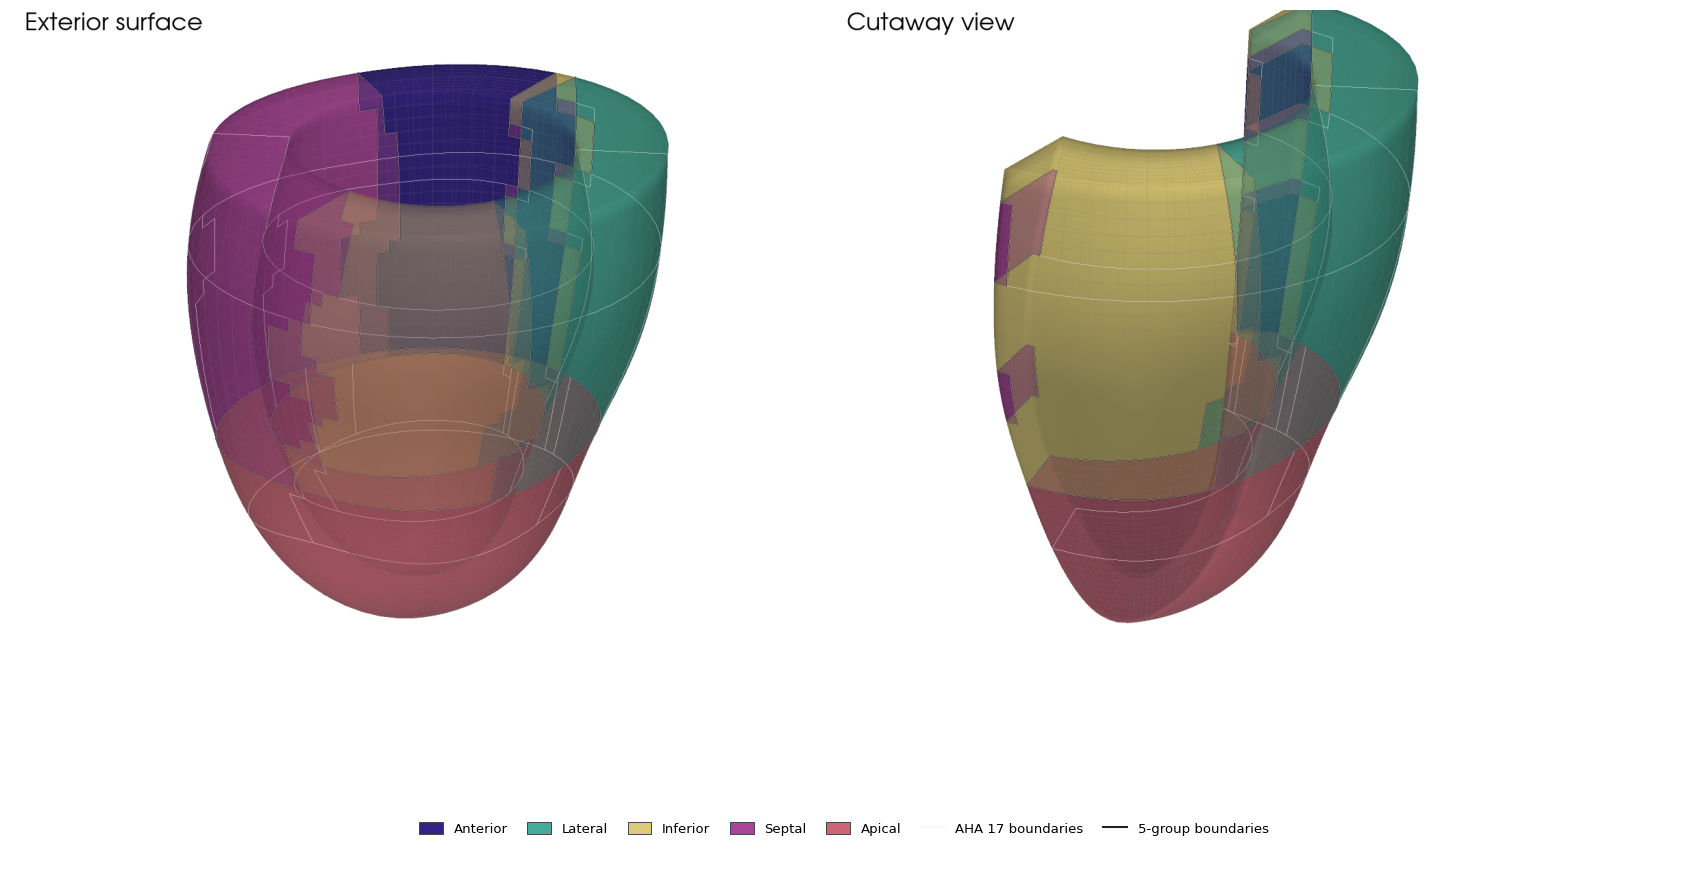

Saved figure: output_dir\lv_aha5_grouped_surface_cutaway.png


In [10]:
# =========================
# 8) 生成双视图（整体表面 + cutaway）+ 底部 legend
# =========================
use_transparent = (bg_mode == "transparent")

img_raw = render_pyvista_dual(
    grid,
    window_size=window_size,
    transparent=use_transparent,
    zoom=zoom_factor,
    opacity=mesh_opacity,
)

print(f"Raw screenshot shape : {img_raw.shape}, dtype: {img_raw.dtype}")

if img_raw.shape[-1] >= 3:
    rgb = img_raw[..., :3]
    nonwhite_ratio = float((rgb.min(axis=-1) < 250).mean())
    print(f"Non-background pixel ratio: {nonwhite_ratio:.3f}")
    if nonwhite_ratio < 0.01:
        print("[WARN] 整张图几乎全是背景色 —— 请回到 PyVista 自检部分确认渲染是否正常。")

compose_with_legend(
    img_raw,
    figure_path,
    transparent=use_transparent,
    dpi=mpl_dpi,
    legend_ncol=7,
)
print(f"Saved figure: {figure_path}")


## 可选：在 notebook 中交互旋转查看

下面这个 cell 会显示一个可交互旋转的双视图。
如果 `trame` backend 不可用，代码会自动提示并尝试回退。


In [11]:
# 可选：显示可交互旋转的双视图
# 如果已经安装 pyvista[jupyter]，但这里仍然无法交互显示，请先重启 kernel 再运行本 cell。

show_interactive_dual(
    grid,
    backend=interactive_backend,
    window_size=interactive_window_size,
    zoom=zoom_factor,
    opacity=mesh_opacity,
)


Widget(value='<iframe src="http://localhost:6346/index.html?ui=P_0x1f2dc7fd130_0&reconnect=auto" class="pyvist…

## 可选：单独查看 lateral 组的三维形状

这一部分不再输出 cutaway-only 图，而是单独输出 lateral 组的形状。


Widget(value='<iframe src="http://localhost:6346/index.html?ui=P_0x1f2dc9f3440_1&reconnect=auto" class="pyvist…

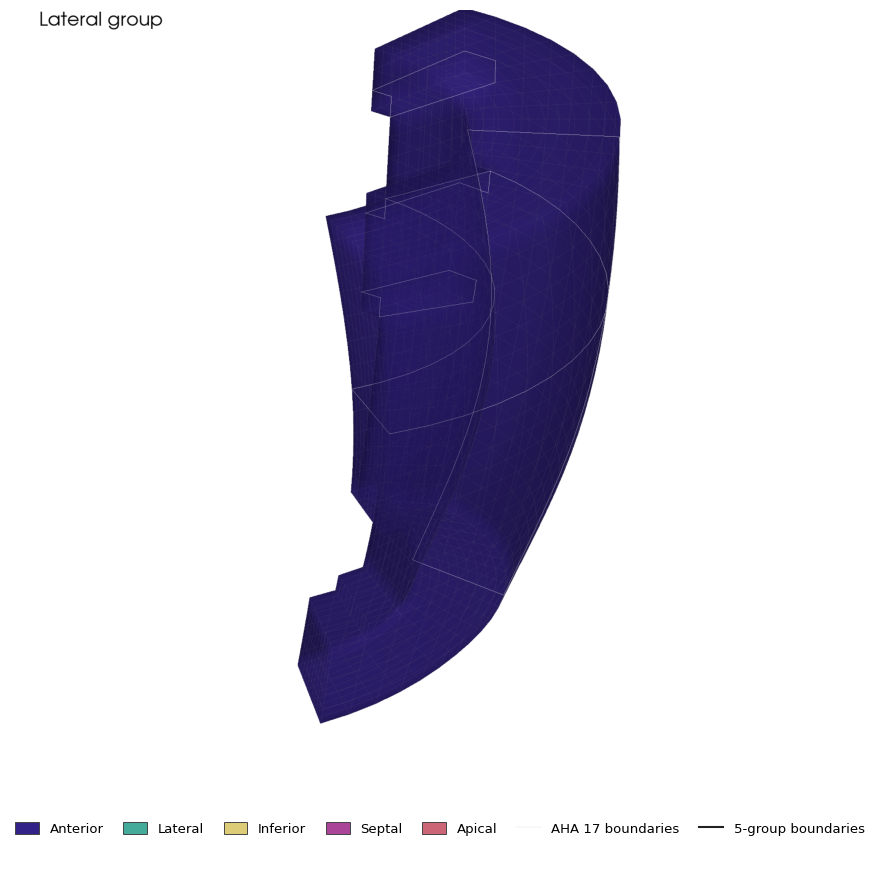

Saved figure: output_dir\lv_lateral_group_only.png


In [12]:
# 单独渲染 lateral 组 + 底部 legend
use_transparent = (bg_mode == "transparent")

img_group = render_single_group(
    grid,
    group_id=single_group_id,
    group_name=single_group_name,
    transparent=use_transparent,
    zoom=1.15,
    opacity=min(0.95, mesh_opacity + 0.06),
    window_size=(1500, 1400),
)

compose_with_legend(
    img_group,
    single_group_path,
    transparent=use_transparent,
    dpi=mpl_dpi,
    legend_ncol=7,
)
print(f"Saved figure: {single_group_path}")


## 使用说明

- 先运行导入、自检、配置与数据读取部分；
- 主图使用 **5 组染色**（AHA5），但同时保留 **AHA17 细边界** 与 **AHA5 粗边界**；
- `mesh_opacity` 用于统一调节彩色表面的透明度；
- `show_mesh_overlay` 用于控制是否保留整体网格线框；
- 第二个可选单图现在显示 **lateral 组** 的三维形状，而不是 cutaway-only 图；
- 若已安装 `pyvista[jupyter]`，通常重启 kernel 后运行交互 cell 即可在 notebook 中旋转查看。
